# Ch6 Playground — 逆矩陣、列空間、秩與零空間

> 對應 3Blue1Brown《線性代數的本質》第六章
>
> **一句話總結**：這一章回答的核心問題是 — 給定 $A\vec{x} = \vec{b}$，我們能不能「倒回去」找到 $\vec{x}$？什麼時候可以，什麼時候不行？

---

## 全局觀：四個概念如何串在一起

想像你有一個線性變換 $A$：

| 問題 | 對應概念 |
|---|---|
| 能不能「倒回去」？ | **逆矩陣** $A^{-1}$ — 存在的條件是 $\det(A) \neq 0$ |
| 變換之後，輸出能到達哪些地方？ | **列空間 (Column Space)** — $A$ 的所有 column 能張開的空間 |
| 輸出的空間有幾維？ | **秩 (Rank)** — 列空間的維度 |
| 哪些輸入會被壓扁到原點？ | **零空間 (Null Space)** — 滿足 $A\vec{x} = \vec{0}$ 的所有 $\vec{x}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.grid'] = True

print("Ready!")

Ready!


In [2]:
# ========== 通用繪圖工具 ==========

def plot_transform(M, vectors=None, title="", ax=None, lim=4):
    """畫出矩陣 M 對單位正方形的變換，可額外標記向量"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    M = np.array(M, dtype=float)
    
    square = np.array([[0,0],[1,0],[1,1],[0,1]])
    transformed = (M @ square.T).T
    
    ax.add_patch(plt.Polygon(square, alpha=0.15, color='skyblue', edgecolor='blue', lw=2))
    ax.add_patch(plt.Polygon(transformed, alpha=0.25, color='salmon', edgecolor='red', lw=2))
    
    # 基底向量
    ax.quiver(0, 0, M[0,0], M[1,0], angles='xy', scale_units='xy', scale=1,
              color='red', width=0.015, zorder=5)
    ax.quiver(0, 0, M[0,1], M[1,1], angles='xy', scale_units='xy', scale=1,
              color='green', width=0.015, zorder=5)
    
    if vectors:
        colors = ['purple', 'orange', 'brown', 'magenta']
        for i, (v, label) in enumerate(vectors):
            v = np.array(v, dtype=float)
            c = colors[i % len(colors)]
            ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                      color=c, width=0.012, zorder=6)
            ax.annotate(label, xy=(v[0], v[1]), fontsize=11, color=c,
                       fontweight='bold', xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    if title:
        det = np.linalg.det(M)
        ax.set_title(f"{title}\ndet = {det:.2f}", fontsize=12)
    return ax

---
## Part 1：逆矩陣 — 「倒帶」一個變換

### 理論

$A$ 把空間變形了，$A^{-1}$ 就是把空間「變回來」。

$$A \cdot A^{-1} = A^{-1} \cdot A = I$$

幾何直覺：如果 $A$ 是「旋轉 90°」，$A^{-1}$ 就是「旋轉 -90°」。
如果 $A$ 是「x 方向拉伸 2 倍」，$A^{-1}$ 就是「x 方向縮回 1/2」。

**關鍵問題**：什麼時候 $A^{-1}$ 不存在？
→ 當 $\det(A) = 0$ 時！因為 $A$ 把空間壓扁了（降維），你無法從一條線「倒推」回一個平面。

In [3]:
# === 實驗 1a：逆矩陣 = 「倒帶」 ===

# 一個可逆的變換
A = np.array([[2, 1],
              [1, 3]])

print("A =")
print(A)
print(f"det(A) = {np.linalg.det(A):.2f}  ← 不為零，所以可逆！")
print()

# 計算逆矩陣
A_inv = np.linalg.inv(A)
print("A⁻¹ =")
print(A_inv)
print()

# 驗證：A × A⁻¹ = I
print("A @ A⁻¹ =")
print(np.round(A @ A_inv, 10))  # round 掉浮點誤差
print("→ 單位矩陣！變換再倒帶 = 什麼都沒做")

A =
[[2 1]
 [1 3]]
det(A) = 5.00  ← 不為零，所以可逆！

A⁻¹ =
[[ 0.6 -0.2]
 [-0.2  0.4]]

A @ A⁻¹ =
[[ 1.  0.]
 [-0.  1.]]
→ 單位矩陣！變換再倒帶 = 什麼都沒做


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1032888840.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(square, alpha=0.15, color='skyblue', edgecolor='blue', lw=2))
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1032888840.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(transformed, alpha=0.25, color='salmon', edgecolor='red', lw=2))


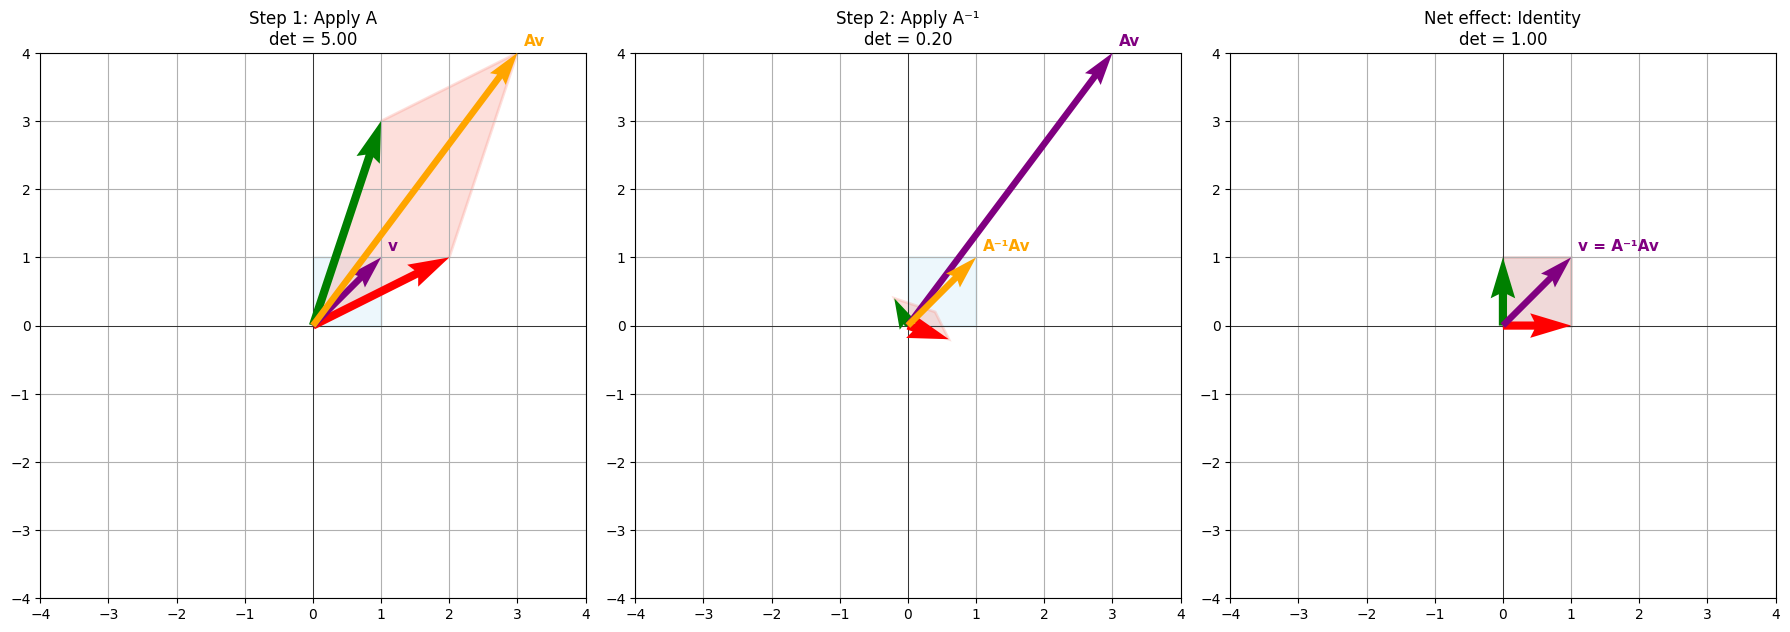

v = [1 1] → Av = [3 4] → A⁻¹(Av) = [1. 1.]
→ 完美倒帶回原點！


In [4]:
# === 實驗 1b：視覺化「變換 → 倒帶」 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 原始向量
v = np.array([1, 1])

# Step 1：A 把 v 變成 Av
Av = A @ v
plot_transform(A, vectors=[([1,1], 'v'), (Av, 'Av')], title="Step 1: Apply A", ax=axes[0])

# Step 2：A⁻¹ 把 Av 變回 v
recovered = A_inv @ Av
plot_transform(A_inv, vectors=[(Av, 'Av'), (recovered, 'A⁻¹Av')], 
               title="Step 2: Apply A⁻¹", ax=axes[1])

# Step 3：A⁻¹A = I
plot_transform(np.eye(2), vectors=[([1,1], 'v = A⁻¹Av')], 
               title="Net effect: Identity", ax=axes[2])

plt.tight_layout()
plt.show()
print(f"v = {v} → Av = {Av} → A⁻¹(Av) = {np.round(recovered, 10)}")
print("→ 完美倒帶回原點！")

In [5]:
# === 實驗 1c：解線性方程 Ax = b ===
# 這就是逆矩陣最實用的功能！
# 如果 A 可逆：x = A⁻¹ b

# 問題：找到 x 使得 A @ x = b
b = np.array([7, 13])

x = A_inv @ b
print(f"問題：A @ x = {b}")
print(f"解：  x = A⁻¹ @ b = {np.round(x, 10)}")
print()

# 驗證
print(f"驗證：A @ x = {A @ x}")
print(f"       b   = {b}")
print(f"一致？{np.allclose(A @ x, b)}")
print()
print("np.linalg.solve(A, b) 是更數值穩定的做法：")
x_solve = np.linalg.solve(A, b)
print(f"x = {x_solve}")

問題：A @ x = [ 7 13]
解：  x = A⁻¹ @ b = [1.6 3.8]

驗證：A @ x = [ 7. 13.]
       b   = [ 7 13]
一致？True

np.linalg.solve(A, b) 是更數值穩定的做法：
x = [1.6 3.8]


A_singular =
[[2 4]
 [1 2]]
det = 0.00  ← 為零！

LinAlgError: 矩陣不可逆！



/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1032888840.py:12: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(square, alpha=0.15, color='skyblue', edgecolor='blue', lw=2))
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1032888840.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Polygon(transformed, alpha=0.25, color='salmon', edgecolor='red', lw=2))


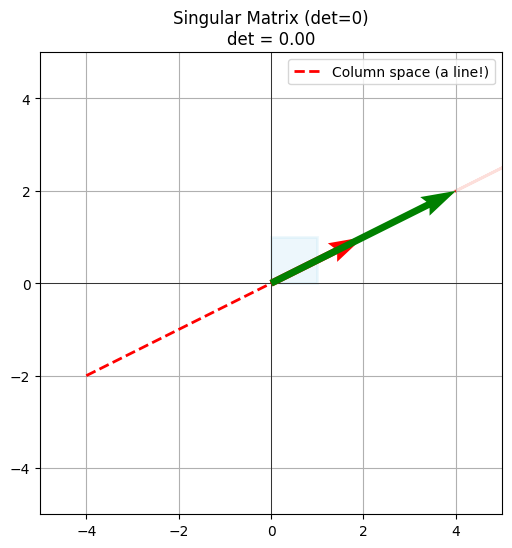

→ 整個 2D 平面被壓扁到一條紅色虛線上
→ 你無法從一條線「倒推」出原來在平面上的哪個點


In [6]:
# === 實驗 1d：不可逆的情況 — det = 0 ===

# 這個矩陣的兩個 column 成比例 → 線性相依 → 把 2D 壓成 1D
A_singular = np.array([[2, 4],
                        [1, 2]])

print("A_singular =")
print(A_singular)
print(f"det = {np.linalg.det(A_singular):.2f}  ← 為零！")
print()

# 試試看求逆
try:
    inv = np.linalg.inv(A_singular)
    print("A⁻¹ =", inv)
    print("⚠️  NumPy 可能不會報錯，但結果是垃圾（數值極大且不穩定）")
    print(f"驗證 A @ A⁻¹ =\n{A_singular @ inv}")
    print("→ 根本不是單位矩陣！")
except np.linalg.LinAlgError:
    print("LinAlgError: 矩陣不可逆！")

print()

# 視覺化：空間被壓成一條線
fig, ax = plt.subplots(figsize=(6, 6))
plot_transform(A_singular, title="Singular Matrix (det=0)", ax=ax, lim=5)

# 畫出壓扁後的「線」
t = np.linspace(-2, 2, 100)
col_dir = A_singular[:, 0]  # column 的方向
ax.plot(t * col_dir[0], t * col_dir[1], 'r--', lw=2, label='Column space (a line!)')
ax.legend(fontsize=10)
plt.show()
print("→ 整個 2D 平面被壓扁到一條紅色虛線上")
print("→ 你無法從一條線「倒推」出原來在平面上的哪個點")

---
## Part 2：列空間 (Column Space) — 「變換能到達的地方」

### 理論

矩陣 $A$ 的**列空間**就是 $A$ 的所有 column 向量的所有線性組合。

幾何直覺：當你把每一個可能的輸入向量 $\vec{x}$ 丟進 $A$，輸出 $A\vec{x}$ 能落在哪裡？
那個「能落在的地方」就是列空間。

- **滿秩 (Full Rank)** 的 2×2 矩陣：列空間 = 整個 2D 平面（輸出能到任何地方）
- **Rank 1** 的 2×2 矩陣：列空間 = 一條線（輸出只能落在一條線上）
- **零矩陣**：列空間 = 原點

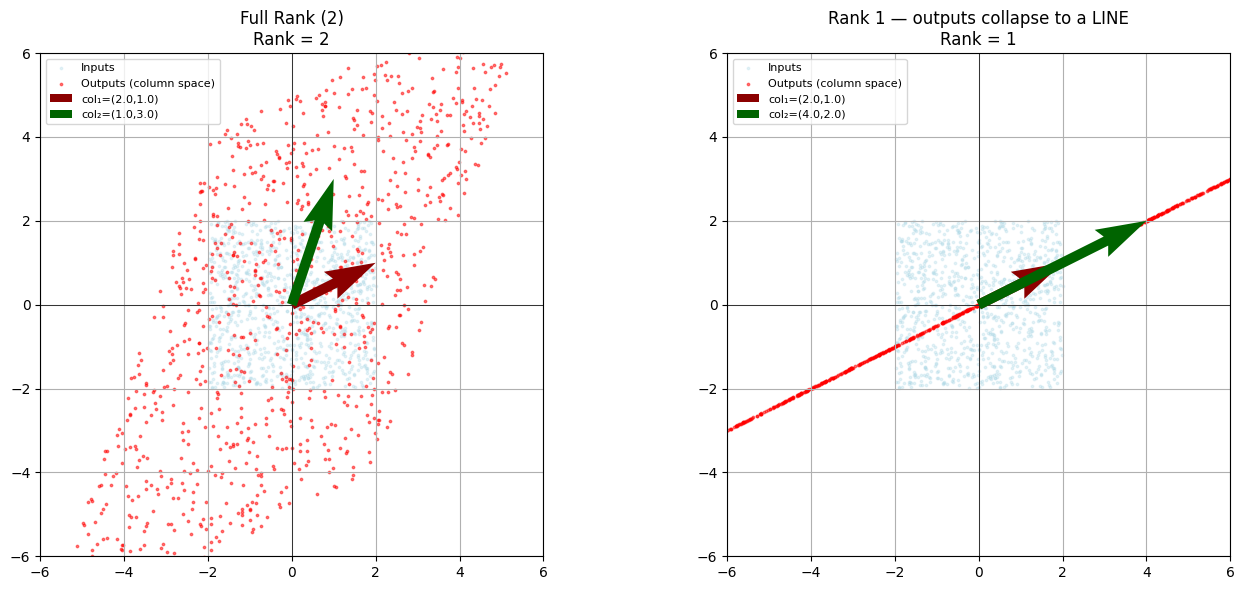

左圖：兩個 column 線性獨立 → 輸出散布在整個平面 → rank = 2
右圖：兩個 column 成比例 → 輸出全部壓在一條線上 → rank = 1


In [7]:
# === 實驗 2a：用大量隨機點視覺化列空間 ===

def visualize_column_space(M, title="", ax=None):
    """把大量隨機輸入丟進 M，看輸出落在哪裡"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    M = np.array(M, dtype=float)
    
    # 產生 1000 個隨機輸入（均勻分布在 [-2, 2] 的方形裡）
    np.random.seed(42)
    inputs = np.random.uniform(-2, 2, size=(2, 1000))
    
    # 全部丟進變換
    outputs = M @ inputs
    
    # 畫輸入（灰色）和輸出（紅色）
    ax.scatter(inputs[0], inputs[1], c='lightblue', s=3, alpha=0.3, label='Inputs')
    ax.scatter(outputs[0], outputs[1], c='red', s=3, alpha=0.5, label='Outputs (column space)')
    
    # 畫 column 向量
    ax.quiver(0, 0, M[0,0], M[1,0], angles='xy', scale_units='xy', scale=1,
              color='darkred', width=0.02, zorder=10, label=f'col₁=({M[0,0]:.1f},{M[1,0]:.1f})')
    ax.quiver(0, 0, M[0,1], M[1,1], angles='xy', scale_units='xy', scale=1,
              color='darkgreen', width=0.02, zorder=10, label=f'col₂=({M[0,1]:.1f},{M[1,1]:.1f})')
    
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    
    rank = np.linalg.matrix_rank(M)
    ax.set_title(f"{title}\nRank = {rank}", fontsize=12)
    ax.legend(fontsize=8, loc='upper left')
    return ax

# 對比：滿秩 vs Rank 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 滿秩：輸出散布在整個 2D 平面
visualize_column_space([[2, 1], [1, 3]], title="Full Rank (2)", ax=axes[0])

# Rank 1：輸出全部落在一條線上！
visualize_column_space([[2, 4], [1, 2]], title="Rank 1 — outputs collapse to a LINE", ax=axes[1])

plt.tight_layout()
plt.show()
print("左圖：兩個 column 線性獨立 → 輸出散布在整個平面 → rank = 2")
print("右圖：兩個 column 成比例 → 輸出全部壓在一條線上 → rank = 1")

---
## Part 3：秩 (Rank) — 「輸出空間的維度」

### 理論

**Rank = 列空間的維度 = 變換後空間還剩幾維**

| 情境 | Rank | 意義 |
|---|---|---|
| 2×2 矩陣，rank = 2 | 滿秩 | 2D → 2D，沒有壓縮，可逆 |
| 2×2 矩陣，rank = 1 | 降秩 | 2D → 1D，壓成一條線，不可逆 |
| 2×2 矩陣，rank = 0 | 零矩陣 | 2D → 0D，壓成一個點，不可逆 |
| 3×3 矩陣，rank = 2 | 降秩 | 3D → 2D，立方體壓成一個平面 |

Rank 和 det 的關係：**滿秩 ↔ det ≠ 0 ↔ 可逆**

In [8]:
# === 實驗 3a：各種 Rank 的情況 ===

matrices = {
    "Rank 2 (full)": np.array([[2, 1], [1, 3]]),
    "Rank 1 (line)": np.array([[2, 4], [1, 2]]),
    "Rank 0 (point)": np.array([[0, 0], [0, 0]]),
}

for name, M in matrices.items():
    rank = np.linalg.matrix_rank(M)
    det = np.linalg.det(M)
    print(f"{name}:")
    print(f"  Matrix = {M.tolist()}")
    print(f"  np.linalg.matrix_rank = {rank}")
    print(f"  det = {det:.2f}")
    print(f"  可逆？{'是' if rank == M.shape[0] else '否'}")
    print()

Rank 2 (full):
  Matrix = [[2, 1], [1, 3]]
  np.linalg.matrix_rank = 2
  det = 5.00
  可逆？是

Rank 1 (line):
  Matrix = [[2, 4], [1, 2]]
  np.linalg.matrix_rank = 1
  det = 0.00
  可逆？否

Rank 0 (point):
  Matrix = [[0, 0], [0, 0]]
  np.linalg.matrix_rank = 0
  det = 0.00
  可逆？否



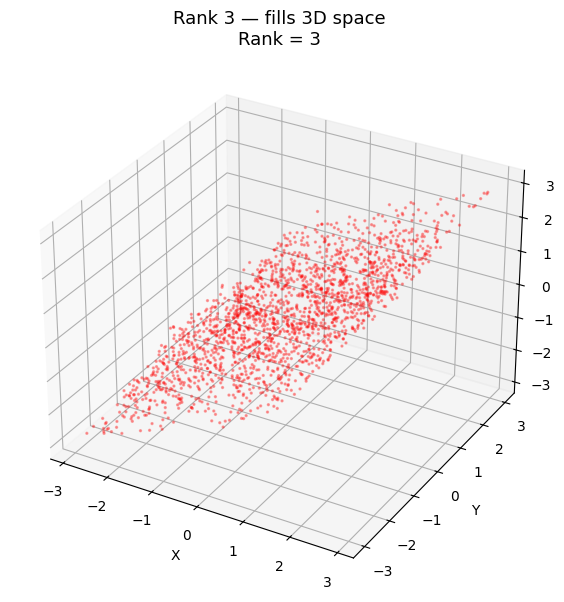

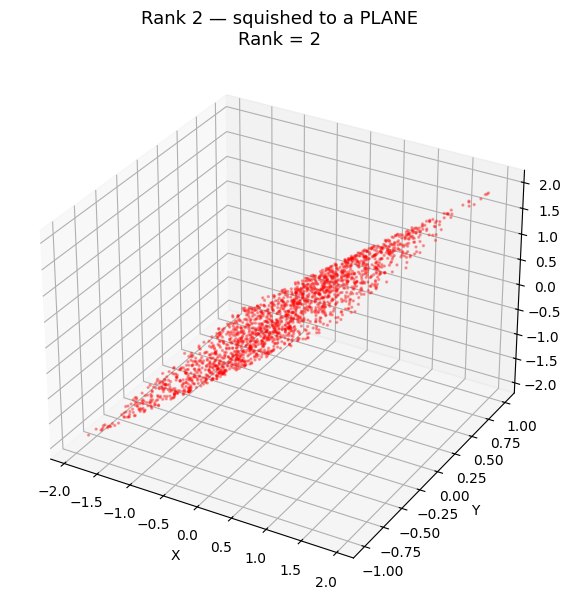

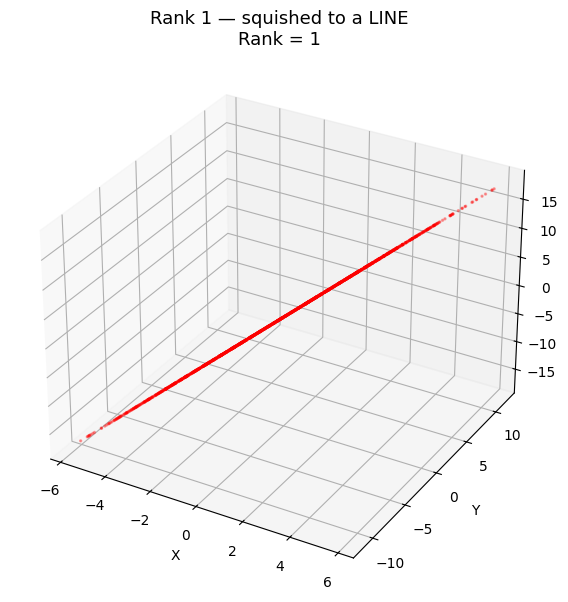

In [12]:
# === 實驗 3b：3D 矩陣的三種 Rank（3D → 3D / 2D / 1D）===
from mpl_toolkits.mplot3d import Axes3D

def visualize_3d_column_space(M, title=""):
    M = np.array(M, dtype=float)
    np.random.seed(42)
    inputs = np.random.uniform(-1, 1, size=(3, 2000))
    outputs = M @ inputs
    
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(outputs[0], outputs[1], outputs[2], c='red', s=2, alpha=0.3)
    
    rank = np.linalg.matrix_rank(M)
    ax.set_title(f"{title}\nRank = {rank}", fontsize=13)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()

# Rank 3：輸出填滿 3D 空間
visualize_3d_column_space(
    [[2,0,1],[0,3,0],[1,0,2]], 
    title="Rank 3 — fills 3D space"
)

# Rank 2：3D 被壓成一個平面
visualize_3d_column_space(
    [[1,0,1],[0,1,0],[1,0,1]], 
    title="Rank 2 — squished to a PLANE"
)

# Rank 1：3D 被壓成一條線
visualize_3d_column_space(
    [[1,2,3],[2,4,6],[3,6,9]], 
    title="Rank 1 — squished to a LINE"
)

---
## Part 4：零空間 (Null Space / Kernel) — 「被壓扁到原點的那些傢伙」

### 理論

零空間是所有滿足 $A\vec{x} = \vec{0}$ 的 $\vec{x}$ 的集合。

換句話說：**哪些輸入經過變換後會落在原點？**

- 如果 $A$ 可逆（滿秩），零空間只有 $\vec{0}$ 本身 — 只有零向量才會被送到原點
- 如果 $A$ 不可逆（降秩），零空間更大 — 有一整條線（甚至一整個平面）被壓扁到原點

### 秩-零度定理 (Rank-Nullity Theorem)

$$\text{Rank} + \text{Nullity} = n \text{ (column 數)}$$

直覺：輸入空間的維度被「分配」給兩個用途 — 一部分被保留在列空間裡（rank），一部分被壓扁到零空間裡（nullity）。

In [16]:
# === 實驗 4a：用 scipy 求零空間 ===
from scipy.linalg import null_space

# Case 1：滿秩矩陣 — 零空間只有 {0}
A_full = np.array([[2, 1], [1, 3]])
ns_full = null_space(A_full)
print("=== 滿秩矩陣 ===")
print(f"A = {A_full.tolist()},  rank = {np.linalg.matrix_rank(A_full)}")
print(f"零空間的基底向量數 = {ns_full.shape[1]}")
print("→ 零空間只有 {0}，沒有非零向量被壓到原點")
print()

# Case 2：Rank 1 的 2×2 矩陣 — 零空間是一條線
A_rank1 = np.array([[2, 4], [1, 2]])
ns_rank1 = null_space(A_rank1)
print("=== Rank 1 矩陣 ===")
print(f"A = {A_rank1.tolist()},  rank = {np.linalg.matrix_rank(A_rank1)}")
print(f"零空間的基底 =\n{ns_rank1}")
print()

# 驗證：零空間裡的向量乘以 A 確實 = 0
v_null = ns_rank1[:, 0]
print(f"驗證：A @ {np.round(v_null, 4)} = {np.round(A_rank1 @ v_null, 10)}")
print()

# Rank-Nullity 定理
for name, M in [("Full rank", A_full), ("Rank 1", A_rank1)]:
    r = np.linalg.matrix_rank(M)
    ns = null_space(M)
    nullity = ns.shape[1]
    n = M.shape[1]
    print(f"{name}: rank({r}) + nullity({nullity}) = {r + nullity} = n({n})  ✓")

=== 滿秩矩陣 ===
A = [[2, 1], [1, 3]],  rank = 2
零空間的基底向量數 = 0
→ 零空間只有 {0}，沒有非零向量被壓到原點

=== Rank 1 矩陣 ===
A = [[2, 4], [1, 2]],  rank = 1
零空間的基底 =
[[ 0.89442719]
 [-0.4472136 ]]

驗證：A @ [ 0.8944 -0.4472] = [0. 0.]

Full rank: rank(2) + nullity(0) = 2 = n(2)  ✓
Rank 1: rank(1) + nullity(1) = 2 = n(2)  ✓


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1489320004.py:55: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1489320004.py:55: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1489320004.py:55: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1489320004.py:55: UserWarning: Glyph 34253 (\N{CJK UNIFIED IDEOGRAPH-85CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_22152/1489320004.py:55: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd

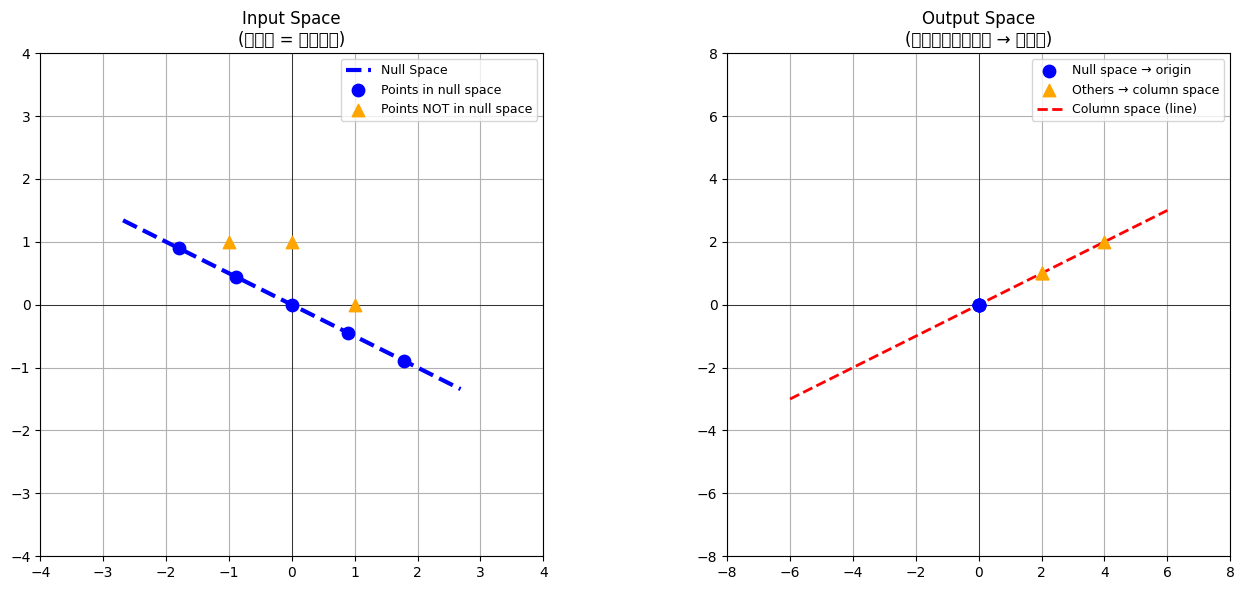

左圖的藍色點（在零空間上）全部被壓到右圖的原點 (0,0)
左圖的橘色點（不在零空間上）被送到右圖的紅色線（列空間）上


In [15]:
# === 實驗 4b：視覺化零空間 ===
# 把零空間的向量（以及零空間附近的向量）畫出來，觀察它們被送到哪裡

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

A_rank1 = np.array([[2, 4], [1, 2]])
ns = null_space(A_rank1)[:, 0]  # 零空間的方向

# 左圖：輸入空間，標記零空間的方向
ax = axes[0]
ax.set_title("Input Space\n(零空間 = 藍色虛線)", fontsize=12)

# 畫零空間方向（一整條線）
t = np.linspace(-3, 3, 100)
ax.plot(t * ns[0], t * ns[1], 'b--', lw=3, label='Null Space', zorder=5)

# 在零空間上取幾個點
null_points = np.array([ns * s for s in [-2, -1, 0, 1, 2]])
ax.scatter(null_points[:, 0], null_points[:, 1], c='blue', s=80, zorder=10, 
           label='Points in null space')

# 也取幾個不在零空間上的點
other_points = np.array([[1, 0], [0, 1], [-1, 1]])
ax.scatter(other_points[:, 0], other_points[:, 1], c='orange', s=80, zorder=10,
           marker='^', label='Points NOT in null space')

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.legend(fontsize=9)

# 右圖：輸出空間，看這些點被送到哪裡
ax = axes[1]
ax.set_title("Output Space\n(零空間裡的點全部 → 原點！)", fontsize=12)

# 零空間的點 → 全部到原點
null_outputs = (A_rank1 @ null_points.T).T
ax.scatter(null_outputs[:, 0], null_outputs[:, 1], c='blue', s=80, zorder=10,
           label='Null space → origin')

# 其他點 → 落在列空間（一條線）上
other_outputs = (A_rank1 @ other_points.T).T
ax.scatter(other_outputs[:, 0], other_outputs[:, 1], c='orange', s=80, zorder=10,
           marker='^', label='Others → column space')

# 畫列空間方向
col_dir = A_rank1[:, 0]
ax.plot(t * col_dir[0], t * col_dir[1], 'r--', lw=2, label='Column space (line)')

ax.set_xlim(-8, 8); ax.set_ylim(-8, 8)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("左圖的藍色點（在零空間上）全部被壓到右圖的原點 (0,0)")
print("左圖的橘色點（不在零空間上）被送到右圖的紅色線（列空間）上")

---
## Part 5：零空間為什麼讓解不唯一？

### 理論

回到核心問題 $A\vec{x} = \vec{b}$：

- 假設你找到了一個解 $\vec{x}_0$
- 如果零空間裡有非零向量 $\vec{n}$（也就是 $A\vec{n} = \vec{0}$）
- 那麼 $\vec{x}_0 + \vec{n}$ 也是解！因為 $A(\vec{x}_0 + \vec{n}) = A\vec{x}_0 + A\vec{n} = \vec{b} + \vec{0} = \vec{b}$

→ 零空間越大，解越多。滿秩時零空間只有 $\{\vec{0}\}$，解唯一。

In [17]:
# === 實驗 5：零空間讓解不唯一 ===

# 一個 rank-1 的矩陣（2D 壓成 1D）
A = np.array([[1, 2],
              [2, 4]])

# 目標向量（必須在列空間上才有解）
b = np.array([5, 10])

# 一個特解（手動找：x₁ + 2x₂ = 5，取 x₂=0 → x₁=5）
x0 = np.array([5, 0])
print(f"特解 x₀ = {x0}")
print(f"驗證：A @ x₀ = {A @ x0}  ✓")
print()

# 零空間的方向
ns = null_space(A)[:, 0]
print(f"零空間方向 n = {np.round(ns, 4)}")
print(f"驗證：A @ n = {np.round(A @ ns, 10)}  ← 是零！")
print()

# x₀ + t*n 對任何 t 都是解！
print("所有解 = x₀ + t·n :")
for t in [-2, -1, 0, 1, 2, 3]:
    x = x0 + t * ns
    result = A @ x
    print(f"  t={t:+d}: x = {np.round(x, 3)},  A@x = {np.round(result, 10)}")

print()
print("→ 無限多個解！全部在一條平行於零空間的線上")

特解 x₀ = [5 0]
驗證：A @ x₀ = [ 5 10]  ✓

零空間方向 n = [-0.8944  0.4472]
驗證：A @ n = [0. 0.]  ← 是零！

所有解 = x₀ + t·n :
  t=-2: x = [ 6.789 -0.894],  A@x = [ 5. 10.]
  t=-1: x = [ 5.894 -0.447],  A@x = [ 5. 10.]
  t=+0: x = [5. 0.],  A@x = [ 5. 10.]
  t=+1: x = [4.106 0.447],  A@x = [ 5. 10.]
  t=+2: x = [3.211 0.894],  A@x = [ 5. 10.]
  t=+3: x = [2.317 1.342],  A@x = [ 5. 10.]

→ 無限多個解！全部在一條平行於零空間的線上


/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

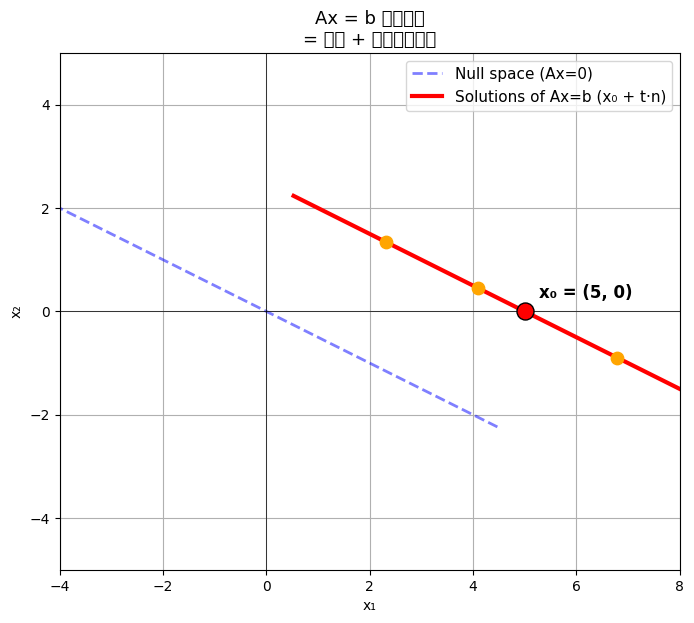

紅線上的每一個點都是 Ax = b 的解
紅線和藍線平行 — 解的集合 = 零空間平移到特解的位置


In [18]:
# === 實驗 5 視覺化：解的集合 = 特解 + 零空間 ===

fig, ax = plt.subplots(figsize=(8, 8))

A = np.array([[1, 2], [2, 4]])
x0 = np.array([5, 0])
ns = null_space(A)[:, 0]

t = np.linspace(-5, 5, 200)

# 零空間（過原點）
ax.plot(t * ns[0], t * ns[1], 'b--', lw=2, alpha=0.5, label='Null space (Ax=0)')

# 解的集合（過 x₀，平行於零空間）
solutions_x = x0[0] + t * ns[0]
solutions_y = x0[1] + t * ns[1]
ax.plot(solutions_x, solutions_y, 'r-', lw=3, label='Solutions of Ax=b (x₀ + t·n)')

# 標記特解
ax.scatter(*x0, c='red', s=150, zorder=10, edgecolors='black')
ax.annotate('x₀ = (5, 0)', xy=x0, fontsize=12, fontweight='bold',
            xytext=(10, 10), textcoords='offset points')

# 標記幾個其他的解
for tt in [-2, 1, 3]:
    sol = x0 + tt * ns
    ax.scatter(*sol, c='orange', s=80, zorder=10)

ax.set_xlim(-4, 8); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title("Ax = b 的所有解\n= 特解 + 零空間的平移", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
plt.show()

print("紅線上的每一個點都是 Ax = b 的解")
print("紅線和藍線平行 — 解的集合 = 零空間平移到特解的位置")

---
## Part 6：全部串起來 — 綜合診斷工具

把上面學到的所有概念包成一個函式，輸入任意矩陣就幫你做完整的診斷。

In [19]:
# === 綜合診斷工具 ===

def diagnose_matrix(M):
    """輸入一個矩陣，印出它的所有關鍵性質"""
    M = np.array(M, dtype=float)
    m, n = M.shape
    
    print("=" * 50)
    print(f"矩陣 ({m}×{n}):")
    print(M)
    print("=" * 50)
    
    # Rank
    rank = np.linalg.matrix_rank(M)
    print(f"\n📐 Rank = {rank}")
    if rank == min(m, n):
        print("   → 滿秩！")
    else:
        print(f"   → 降秩（滿秩應為 {min(m, n)}）")
    
    # Determinant（只有方陣）
    if m == n:
        det = np.linalg.det(M)
        print(f"\n📏 det = {det:.4f}")
        if abs(det) > 1e-10:
            print("   → det ≠ 0 → 可逆")
        else:
            print("   → det ≈ 0 → 不可逆（奇異矩陣）")
    
    # Column Space
    print(f"\n📊 列空間 (Column Space):")
    print(f"   維度 = {rank}")
    if rank == m:
        print(f"   → 列空間 = 整個 R^{m}（輸出能到任何地方）")
    else:
        print(f"   → 列空間是 R^{m} 中的 {rank} 維子空間")
    
    # Null Space
    ns = null_space(M)
    nullity = ns.shape[1]
    print(f"\n🕳️  零空間 (Null Space):")
    print(f"   維度 (nullity) = {nullity}")
    if nullity == 0:
        print("   → 零空間只有 {0}，Ax=b 若有解則唯一")
    else:
        print(f"   → 零空間是 {nullity} 維的，Ax=b 若有解則有無限多個")
        print(f"   基底向量：")
        for i in range(nullity):
            print(f"     n{i+1} = {np.round(ns[:, i], 4)}")
    
    # Rank-Nullity
    print(f"\n✅ Rank-Nullity: rank({rank}) + nullity({nullity}) = {rank + nullity} = n({n})")
    
    # 逆矩陣
    if m == n and abs(np.linalg.det(M)) > 1e-10:
        print(f"\n🔄 逆矩陣 A⁻¹:")
        print(np.round(np.linalg.inv(M), 4))

# ===== 試試看！修改這裡的矩陣 =====
diagnose_matrix([
    [1, 2],
    [3, 4]
])

矩陣 (2×2):
[[1. 2.]
 [3. 4.]]

📐 Rank = 2
   → 滿秩！

📏 det = -2.0000
   → det ≠ 0 → 可逆

📊 列空間 (Column Space):
   維度 = 2
   → 列空間 = 整個 R^2（輸出能到任何地方）

🕳️  零空間 (Null Space):
   維度 (nullity) = 0
   → 零空間只有 {0}，Ax=b 若有解則唯一

✅ Rank-Nullity: rank(2) + nullity(0) = 2 = n(2)

🔄 逆矩陣 A⁻¹:
[[-2.   1. ]
 [ 1.5 -0.5]]


In [20]:
# === 多試幾個不同情況！ ===

print(">>> 降秩的 2×2")
diagnose_matrix([[2, 4], [1, 2]])

print("\n\n>>> 3×3 滿秩")
diagnose_matrix([[1, 0, 2], [0, 1, 1], [1, 1, 0]])

print("\n\n>>> 3×3 降秩（rank=2，立方體壓成平面）")
diagnose_matrix([[1, 0, 1], [0, 1, 1], [1, 1, 2]])

>>> 降秩的 2×2
矩陣 (2×2):
[[2. 4.]
 [1. 2.]]

📐 Rank = 1
   → 降秩（滿秩應為 2）

📏 det = 0.0000
   → det ≈ 0 → 不可逆（奇異矩陣）

📊 列空間 (Column Space):
   維度 = 1
   → 列空間是 R^2 中的 1 維子空間

🕳️  零空間 (Null Space):
   維度 (nullity) = 1
   → 零空間是 1 維的，Ax=b 若有解則有無限多個
   基底向量：
     n1 = [ 0.8944 -0.4472]

✅ Rank-Nullity: rank(1) + nullity(1) = 2 = n(2)


>>> 3×3 滿秩
矩陣 (3×3):
[[1. 0. 2.]
 [0. 1. 1.]
 [1. 1. 0.]]

📐 Rank = 3
   → 滿秩！

📏 det = -3.0000
   → det ≠ 0 → 可逆

📊 列空間 (Column Space):
   維度 = 3
   → 列空間 = 整個 R^3（輸出能到任何地方）

🕳️  零空間 (Null Space):
   維度 (nullity) = 0
   → 零空間只有 {0}，Ax=b 若有解則唯一

✅ Rank-Nullity: rank(3) + nullity(0) = 3 = n(3)

🔄 逆矩陣 A⁻¹:
[[ 0.3333 -0.6667  0.6667]
 [-0.3333  0.6667  0.3333]
 [ 0.3333  0.3333 -0.3333]]


>>> 3×3 降秩（rank=2，立方體壓成平面）
矩陣 (3×3):
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

📐 Rank = 2
   → 降秩（滿秩應為 3）

📏 det = 0.0000
   → det ≈ 0 → 不可逆（奇異矩陣）

📊 列空間 (Column Space):
   維度 = 2
   → 列空間是 R^3 中的 2 維子空間

🕳️  零空間 (Null Space):
   維度 (nullity) = 1
   → 零空間是 1 維的，Ax=b 若有解則有無限多個
   基底向量：
